In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter



In [148]:
df = pd.read_csv('./data/spam.csv')

In [149]:
{"spam": (df['Category'] == 'spam').sum(), "ham": (df['Category'] == 'ham').sum()}

{'spam': np.int64(747), 'ham': np.int64(4825)}

In [150]:
df.isna().sum()

Category    0
Message     0
dtype: int64

In [151]:
duplicates = df[df.duplicated(subset=["Message"], keep=False)]
duplicates.sort_values("Message").head(20)

,Category,Message
2124,spam,#ERROR!
717,spam,#ERROR!
505,spam,#ERROR!
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2344,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1050,spam,18 days to Euro2004 kickoff! U will be kept in...
2719,spam,18 days to Euro2004 kickoff! U will be kept in...
2044,spam,4mths half price Orange line rental & latest c...
389,spam,4mths half price Orange line rental & latest c...


In [152]:
df_clean = df.drop_duplicates(subset=["Message"]).copy()
df_clean.shape

(5157, 2)

In [153]:
class_counts = df_clean["Category"].value_counts()
class_counts

Category
ham     4516
spam     641
Name: count, dtype: int64

In [154]:
class_percentages = df_clean["Category"].value_counts(normalize=True) * 100
class_percentages

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

(array([0, 1]), [Text(0, 0, 'ham'), Text(1, 0, 'spam')])

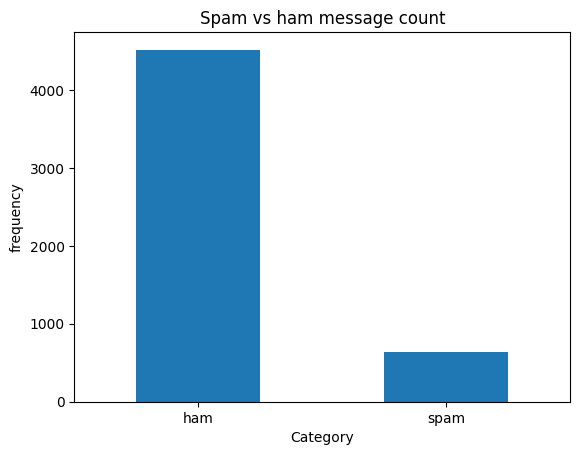

In [155]:
class_counts.plot(kind='bar')

plt.title("Spam vs ham message count")
plt.xlabel("Category")
plt.ylabel("frequency")
plt.xticks(rotation=0)


In [156]:
df_clean['char_count'] = df_clean["Message"].apply(len)
df_clean["word_count"] = df_clean["Message"].apply(lambda x: len(x.split(" ")))

df_clean["avg_word_length"] = df["Message"].apply(
    lambda x: sum(len(word) for word in x.split()) / len(x.split()) if len(x.split()) > 0 else 0
)

In [157]:
length_summary = df_clean.groupby("Category")[['char_count', 'word_count', 'avg_word_length']].mean()
length_summary

,char_count,word_count,avg_word_length
Category,,,
ham,70.869353,14.328388,4.146345
spam,137.118565,23.659906,4.978968


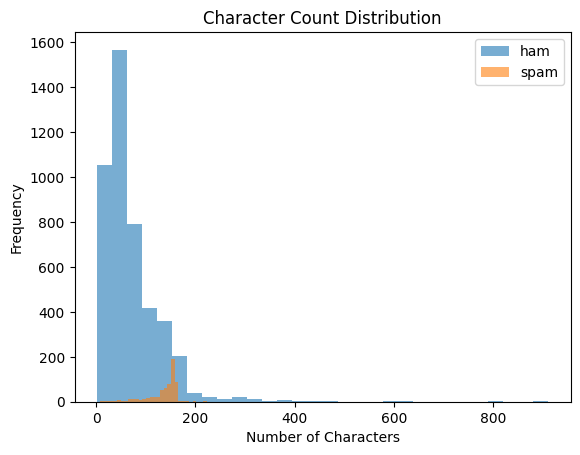

In [158]:
df_clean[df_clean["Category"]=='ham']['char_count'].plot(kind="hist", bins=30, alpha=0.6, label='ham')
df_clean[df_clean["Category"]=='spam']['char_count'].plot(kind="hist", bins=30, alpha=0.6, label='spam')

plt.title("Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.legend()

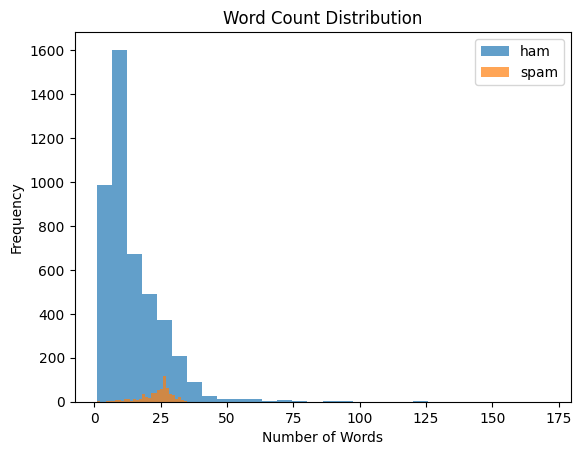

In [159]:
df_clean[df_clean["Category"] == "ham"]["word_count"].plot(kind="hist", bins=30, alpha=0.7, label="ham")
df_clean[df_clean["Category"] == "spam"]["word_count"].plot(kind="hist", bins=30, alpha=0.7, label="spam")

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()

In [160]:
# punctuations count

df_clean["exclamation_count"] = df_clean["Message"].apply(lambda x: x.count("!"))

df_clean["question_count"] = df_clean["Message"].apply(lambda x: x.count("?"))

df_clean["digit_count"] = df_clean["Message"].apply(lambda x: sum(char.isdigit() for char in x))

df_clean["money_symbol_count"] = df_clean["Message"].apply(lambda x: x.count("$") + x.count("£"))

df_clean["uppercase_count"] = df_clean["Message"].apply(lambda x: sum(char.isupper() for char in x))

df_clean["uppercase_ratio"] = df_clean["Message"].apply(
    lambda x: sum(char.isupper() for char in x) / len(x) if len(x) > 0 else 0
)

In [161]:
# summary of all punctuation features 
special_feature_summary = df_clean.groupby("Category")[
    [
        "exclamation_count",
        "question_count",
        "digit_count",
        "money_symbol_count",
        "uppercase_count",
        "uppercase_ratio"
    ]
].mean()

special_feature_summary

,exclamation_count,question_count,digit_count,money_symbol_count,uppercase_count,uppercase_ratio
Category,,,,,,
ham,0.177591,0.29473,0.296723,0.005314,3.982064,0.056994
spam,0.692668,0.24805,15.329173,0.411856,15.132605,0.110670


In [162]:
df_clean['has_url'] = df_clean["Message"].apply(lambda x: 1 if re.search(r"http\S+|www\S+", x.lower()) else 0)
df_clean['has_phone_number'] = df_clean["Message"].apply(lambda x: 1 if re.search(r"\d{5,}", x) else 0)

url_phone_sumamry = df_clean.groupby("Category")[['has_url', 'has_phone_number']].mean()
url_phone_sumamry

,has_url,has_phone_number
Category,,
ham,0.000221,0.000664
spam,0.138846,0.762871


In [163]:
# clean text for word frequency analysis

def clean_text(text):
  text = text.lower()
  text = re.sub(r"[^a-z\s]", " ", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text

df_clean["clean_message"] = df_clean["Message"].apply(clean_text)


In [164]:
stop_words = {
    "the", "a", "an", "and", "or", "is", "are", "to", "for", "in", "of",
    "on", "at", "it", "this", "that", "i", "you", "me", "my", "your",
    "we", "our", "he", "she", "they", "them", "was", "were", "be",
    "been", "am", "with", "as", "by", "from", "but", "if", "so"
}

# function to get common words

def get_common_words(messages, n=20):
    words = []

    for message in messages:
        for word in message.split():
            if word not in stop_words and len(word) > 1:
                words.append(word)

    return Counter(words).most_common(n)


spam_words = get_common_words(df_clean[df_clean["Category"] == "spam"]['clean_message'], 20)
ham_words = get_common_words(df_clean[df_clean["Category"] == "ham"]['clean_message'], 20)

spam_words

[('call', 313),
 ('free', 192),
 ('now', 166),
 ('txt', 139),
 ('ur', 119),
 ('stop', 115),
 ('have', 111),
 ('text', 109),
 ('mobile', 107),
 ('reply', 96),
 ('claim', 94),
 ('www', 81),
 ('prize', 78),
 ('get', 70),
 ('only', 67),
 ('no', 66),
 ('just', 65),
 ('cash', 64),
 ('new', 64),
 ('send', 59)]

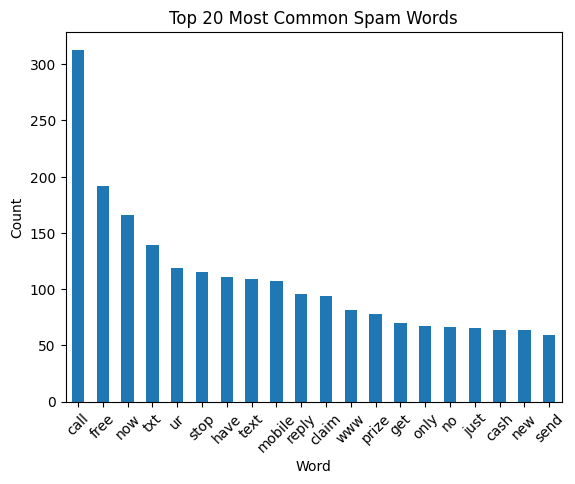

In [165]:
# plot for most common spam words

spam_words_df = pd.DataFrame(spam_words, columns=["word", "count"])

spam_words_df.plot(kind="bar", x="word", y="count", legend=False)

plt.title("Top 20 Most Common Spam Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

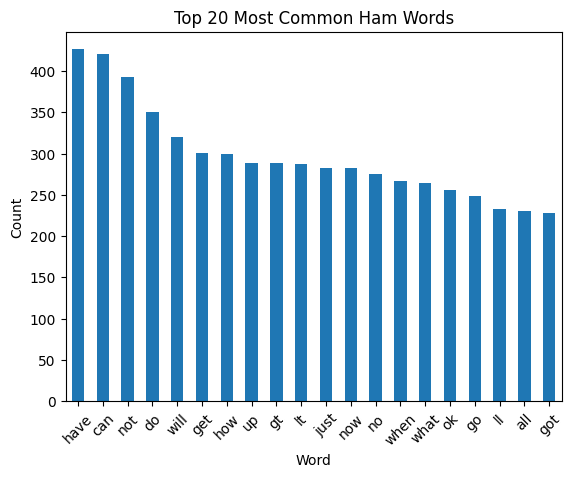

In [166]:
# plot for most common ham words
ham_words_df = pd.DataFrame(ham_words, columns=["word", "count"])

ham_words_df.plot(kind="bar", x="word", y="count", legend=False)

plt.title("Top 20 Most Common Ham Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [167]:
# function that finds bigrams (2-word phrases)

def get_ngrams(messages, ngram_size=2, top_n=20):
    ngrams = []

    for message in messages:
        words = [
            word for word in message.split()
            if word not in stop_words and len(word) > 1
        ]

        for i in range(len(words) - ngram_size + 1):
            ngram = tuple(words[i:i + ngram_size])
            ngrams.append(ngram)

    return Counter(ngrams).most_common(top_n)

spam_bigrams = get_ngrams(df_clean[df_clean["Category"] == "spam"]["clean_message"], 2, 20)
ham_bigrams = get_ngrams(df_clean[df_clean["Category"] == "ham"]["clean_message"], 2, 20)

spam_trigrams = get_ngrams(df_clean[df_clean["Category"] == "spam"]["clean_message"], 3, 20)
ham_trigrams = get_ngrams(df_clean[df_clean["Category"] == "ham"]["clean_message"], 3, 20)


In [168]:
eda_summary = df_clean.groupby("Category").agg(
    message_count=("Message", "count"),
    avg_char_count=("char_count", "mean"),
    avg_word_count=("word_count", "mean"),
    avg_exclamation_count=("exclamation_count", "mean"),
    avg_digit_count=("digit_count", "mean"),
    avg_money_symbol_count=("money_symbol_count", "mean"),
    avg_uppercase_ratio=("uppercase_ratio", "mean"),
    url_rate=("has_url", "mean"),
    phone_number_rate=("has_phone_number", "mean")
)

eda_summary


,message_count,avg_char_count,avg_word_count,avg_exclamation_count,avg_digit_count,avg_money_symbol_count,avg_uppercase_ratio,url_rate,phone_number_rate
Category,,,,,,,,,
ham,4516,70.869353,14.328388,0.177591,0.296723,0.005314,0.056994,0.000221,0.000664
spam,641,137.118565,23.659906,0.692668,15.329173,0.411856,0.110670,0.138846,0.762871


In [169]:
# How are spam messages different from ham messages? 
# Spam messages in general have a higher word count than ham messages and there seems to be a certain set of words that consistently appear in spam 
# messages and in ham messages. spam_words, ham_words, spam_bigrams, ham_bigrams, spam_trigrams, ham_trigrams have the most common words for spam and
# ham and the most common 2 and 3 words phrases in bigrams and trigrams variables respectively. Spam and ham differ in the kind of symbols that are used
# in the messages and spam has more url and phome numbers mentioned in the messages
